In [1]:
states=[i for i in range(101)]
mdp={i:{} for i in range(101)}
values = [0.0]*101
values[100]=1.0


p_heads=0.4
p_tails=0.6
d=1e-9

In [2]:
while True:
    delta=0
    new_values=values.copy()
    for s in range(1,100):
        new_values[s]=0.0
        for a in range(1,min(s,100-s)+1):
            new_values[s]=max(new_values[s],p_heads*values[s+a]+p_tails*values[s-a])
        delta=max(delta,abs(new_values[s]-values[s]))
    values=new_values
   
    if delta<d:
        break

policy=[0]*101
for s in range(1,100):
    best=0
    max_value=-1
    for a in range(1,min(s,100-s)+1):
        bet_a=p_heads*values[s+a]+p_tails*values[s-a]
        if bet_a>max_value:
            max_value=bet_a
            best=a
    policy[s]=best

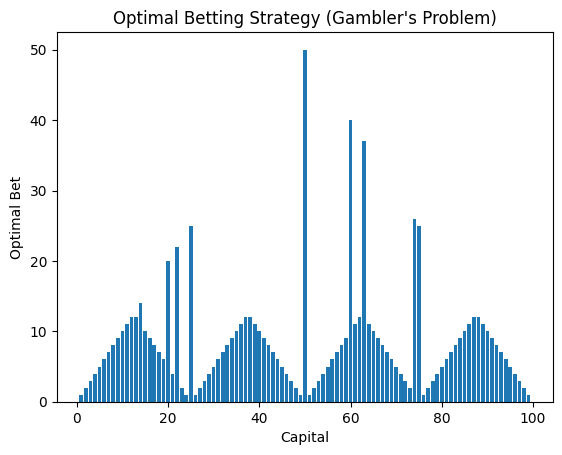

In [3]:
import matplotlib.pyplot as plt

plt.bar(range(1, 100), policy[1:100])
plt.title("Optimal Betting Strategy (Gambler's Problem)")
plt.xlabel("Capital")
plt.ylabel("Optimal Bet")
plt.show()